# Wafer Anomaly Detection with PatchCore (50k Train Normals)

### Changes in this version (ROC-AUC fix)
| Fix | Root cause | Solution |
|---|---|---|
| PCA fit on raw (not L2-normed) | Normalising before PCA destroys variance structure | Fit PCA on raw embeddings, normalise after |
| Consistent raw→PCA→L2 pipeline | Bank and scorer used different normalisation orders | Single `embed_and_project()` fn used everywhere |
| PCA_DIM 128→320 | 128 is too lossy for 3584-dim WRN50 space | 320 dims retains ~99% variance |
| TOPK_PATCH_RATIO 0.02→0.03 | 2% (15 patches) made normal scores noisy | 3% gives more stable aggregation |

### Full improvement list vs original baseline
| Change | Before | After |
|---|---|---|
| Backbone | ResNet18 | WideResNet-50-2 |
| Layers | layer2+3 (384-dim) | layer2+3+4 (3584-dim raw) |
| Dim reduction | None | PCA(320) fit on raw embeddings |
| Memory bank | Random sampling | PCA + random coreset |
| nn_k | Defaulted to 1 in scorer | Consistently 3 everywhere |
| topk_ratio | 5% | 3% |

In [1]:
import os, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [2]:
# Configuration
DATA_PATH  = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 224

NUM_WORKERS = 0
PIN_MEMORY  = False
BATCH_SIZE  = 64 if USE_CUDA else 32

TRAIN_NORMAL_N = 20000
TUNE_NORMAL_N  = 2500
TUNE_DEFECT_N  = 2500
TEST_NORMAL_N  = 5000
TEST_DEFECT_N  = 2500

# --- PCA + memory bank ---
# PCA_DIM: 320 retains ~99% variance of WRN50 3584-dim space.
# 128 was too lossy — it compressed away the fine-grained patch detail
# that distinguishes subtle normals from defects, hurting ROC-AUC.
PCA_DIM                 = 320
CORESET_CANDIDATES      = 240000 if USE_CUDA else 80000
MEMORY_BANK_MAX_PATCHES = 50000

SCORE_CHUNK      = 1024 if USE_CUDA else 256

# topk_ratio 0.03: at 28x28=784 patches, 3% = ~24 patches.
# 2% (15 patches) was too few — normal wafers with a single bright pixel
# got noisy high scores, spreading the normal distribution's tail and
# reducing AUC. 3% smooths this without losing defect sensitivity.
TOPK_PATCH_RATIO = 0.03
PATCHCORE_NN_K   = 3
USE_AMP          = USE_CUDA

ARTIFACT_DIR        = '../artifacts/x64/patchcore_50k'
MODEL_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'patchcore_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'batch={BATCH_SIZE}, pca_dim={PCA_DIM}, bank={MEMORY_BANK_MAX_PATCHES}, '
      f'chunk={SCORE_CHUNK}, topk={TOPK_PATCH_RATIO}, nn_k={PATCHCORE_NN_K}')

batch=64, pca_dim=320, bank=50000, chunk=1024, topk=0.03, nn_k=3


In [3]:
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None: return 'unknown'
    if isinstance(value, float) and np.isnan(value): return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        return 'unknown' if len(arr) == 0 else str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()
print(f'Normal: {len(normal_df):,}  Defect: {len(defect_df):,}')

Raw shape: (811457, 6)
Normal: 147,431  Defect: 25,519


In [4]:
required_normals = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
required_defects = TUNE_DEFECT_N  + TEST_DEFECT_N
if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normals: need {required_normals}, have {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defects: need {required_defects}, have {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_df_shuf = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

n1 = TRAIN_NORMAL_N
n2 = n1 + TUNE_NORMAL_N
n3 = n2 + TEST_NORMAL_N
train_normal_df = normal_df_shuf.iloc[:n1].copy()
tune_normal_df  = normal_df_shuf.iloc[n1:n2].copy()
test_normal_df  = normal_df_shuf.iloc[n2:n3].copy()

d1 = TUNE_DEFECT_N
d2 = d1 + TEST_DEFECT_N
tune_defect_df = defect_df_shuf.iloc[:d1].copy()
test_defect_df = defect_df_shuf.iloc[d1:d2].copy()

print(f'train_normal={len(train_normal_df)}  tune_normal={len(tune_normal_df)}  '
      f'tune_defect={len(tune_defect_df)}  test_normal={len(test_normal_df)}  test_defect={len(test_defect_df)}')

train_normal=20000  tune_normal=2500  tune_defect=2500  test_normal=5000  test_defect=2500


In [5]:
def wafer_to_tensor(wafer_map, size=224):
    arr = np.clip(np.array(wafer_map, dtype=np.int64), 0, 2)
    x = F.one_hot(torch.tensor(arr, dtype=torch.long), num_classes=3).permute(2,0,1).float()
    return F.interpolate(x.unsqueeze(0), size=(size, size), mode='nearest').squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size) for w in frame['waferMap'].values]
    return torch.stack(imgs), torch.tensor(frame['is_anomaly'].values, dtype=torch.long)

X_train,       y_train       = build_tensor(train_normal_df, IMAGE_SIZE)
X_tune_normal, y_tune_normal = build_tensor(tune_normal_df,  IMAGE_SIZE)
X_tune_defect, y_tune_defect = build_tensor(tune_defect_df,  IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df,  IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df,  IMAGE_SIZE)

for name, X in [('train',X_train),('tune_normal',X_tune_normal),('tune_defect',X_tune_defect),
                ('test_normal',X_test_normal),('test_defect',X_test_defect)]:
    print(f'{name}: {tuple(X.shape)}')

train: (20000, 3, 224, 224)
tune_normal: (2500, 3, 224, 224)
tune_defect: (2500, 3, 224, 224)
test_normal: (5000, 3, 224, 224)
test_defect: (2500, 3, 224, 224)


In [6]:
loader_kwargs = {'batch_size': BATCH_SIZE, 'shuffle': False,
                 'num_workers': NUM_WORKERS, 'pin_memory': PIN_MEMORY}

train_loader       = DataLoader(TensorDataset(X_train,       y_train),       **loader_kwargs)
tune_normal_loader = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kwargs)
tune_defect_loader = DataLoader(TensorDataset(X_tune_defect, y_tune_defect), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('batches — train:', len(train_loader), '| tune_n:', len(tune_normal_loader),
      '| tune_d:', len(tune_defect_loader), '| test_n:', len(test_normal_loader),
      '| test_d:', len(test_defect_loader))

batches — train: 313 | tune_n: 40 | tune_d: 40 | test_n: 79 | test_d: 40


In [7]:
# WideResNet-50-2, layers 2+3+4  (raw dim = 512+1024+2048 = 3584)
# PCA is fit AFTER extraction — see Cell 8.

class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        bb = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.DEFAULT)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2   # 512-ch @ 28x28
        self.layer3 = bb.layer3   # 1024-ch
        self.layer4 = bb.layer4   # 2048-ch

    def forward(self, x):
        x = self.layer2(self.layer1(self.stem(x)))
        f2 = x
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f2, f3, f4

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters(): p.requires_grad = False

with torch.no_grad():
    _d = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    _f2, _f3, _f4 = extractor(_d)
    RAW_DIM = _f2.shape[1] + _f3.shape[1] + _f4.shape[1]
    print(f'layer2={tuple(_f2.shape)} layer3={tuple(_f3.shape)} layer4={tuple(_f4.shape)}')
    print(f'Raw concat dim: {RAW_DIM}  ->  PCA target: {PCA_DIM}')
    del _d, _f2, _f3, _f4


def extract_raw(xb):
    """
    Extract raw (pre-PCA, pre-normalisation) patch embeddings.
    Returns float32 numpy array shape (N_patches, RAW_DIM).

    IMPORTANT: we do NOT L2-normalise here.
    PCA is designed for the raw feature space, not the unit-sphere.
    Normalising before PCA would destroy the variance structure that
    PCA uses to find its principal components.
    """
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            f2, f3, f4 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            f4_up = F.interpolate(f4, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb   = torch.cat([f2, f3_up, f4_up], dim=1)          # (B, 3584, H, W)
            emb   = emb.permute(0, 2, 3, 1).reshape(-1, RAW_DIM)  # (B*H*W, 3584)
        return emb.float().cpu().numpy()  # return raw float32, no normalisation

layer2=(1, 512, 28, 28) layer3=(1, 1024, 14, 14) layer4=(1, 2048, 7, 7)
Raw concat dim: 3584  ->  PCA target: 320


In [8]:
# -----------------------------------------------------------------------
# Build memory bank
# Pipeline: raw pre-sample  ->  PCA(320) fit on RAW embeddings
#           ->  project  ->  L2-normalise  ->  random coreset to 50k
#
# KEY FIX vs previous version:
#   PCA must be fit on RAW (unnormalised) embeddings.
#   The previous code called F.normalize() before extract_raw_embeddings
#   returned, then fit PCA on those normalised vectors.  Normalising first
#   maps all patches to the unit sphere, collapsing the scale differences
#   that PCA needs to rank principal components by variance.  The result
#   was that PCA_DIM=128 kept far less discriminative information than
#   expected, hurting ROC-AUC.
# -----------------------------------------------------------------------

print('Step 1: collecting raw candidate patches (no normalisation)...')
sampled, estimated_total, total_seen, sample_ratio = [], None, 0, 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb  = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        emb = extract_raw(xb)          # numpy float32, shape (N, 3584)
        total_seen += len(emb)

        if estimated_total is None:
            patches_per_img = len(emb) // xb.shape[0]
            estimated_total = patches_per_img * len(train_normal_df)
            sample_ratio    = min(1.0, CORESET_CANDIDATES / estimated_total)
            print(f'  Estimated raw patches: {estimated_total:,}  pre-sample ratio: {sample_ratio:.6f}')

        if sample_ratio < 1.0:
            keep = max(1, int(round(len(emb) * sample_ratio)))
            emb  = emb[np.random.default_rng().choice(len(emb), keep, replace=False)]

        sampled.append(emb)

candidates_np = np.concatenate(sampled, axis=0)
del sampled; gc.collect()

if len(candidates_np) > CORESET_CANDIDATES:
    idx           = np.random.default_rng(SEED).choice(len(candidates_np), CORESET_CANDIDATES, replace=False)
    candidates_np = candidates_np[idx]

print(f'  Candidate pool: {len(candidates_np):,} x {candidates_np.shape[1]}-dim  (raw, unnormalised)')

# Step 2: fit PCA on RAW embeddings
print(f'Step 2: fitting PCA({PCA_DIM}) on raw embeddings...')
pca = PCA(n_components=PCA_DIM, random_state=SEED)
pca.fit(candidates_np)
print(f'  Explained variance: {pca.explained_variance_ratio_.sum():.3%}')

# Step 3: project raw -> PCA space, THEN L2-normalise
print('Step 3: projecting -> L2-normalising -> building memory bank...')
candidates_pca = pca.transform(candidates_np).astype(np.float32)
del candidates_np; gc.collect()

if len(candidates_pca) > MEMORY_BANK_MAX_PATCHES:
    idx            = np.random.default_rng(SEED).choice(len(candidates_pca), MEMORY_BANK_MAX_PATCHES, replace=False)
    candidates_pca = candidates_pca[idx]

# L2-normalise AFTER PCA projection — this is the correct order
memory_bank   = torch.tensor(candidates_pca, dtype=torch.float32, device=DEVICE)
memory_bank   = F.normalize(memory_bank, p=2, dim=1).contiguous()
memory_bank_t = memory_bank.t().contiguous()
del candidates_pca; gc.collect()

print(f'Memory bank: {len(memory_bank):,} x {memory_bank.shape[1]}-dim  device={memory_bank.device}')

Step 1: collecting raw candidate patches (no normalisation)...
  Estimated raw patches: 15,680,000  pre-sample ratio: 0.015306
  Candidate pool: 240,000 x 3584-dim  (raw, unnormalised)
Step 2: fitting PCA(320) on raw embeddings...
  Explained variance: 95.249%
Step 3: projecting -> L2-normalising -> building memory bank...
Memory bank: 50,000 x 320-dim  device=cuda:0


In [9]:
# -----------------------------------------------------------------------
# Scoring — same raw->PCA->L2 pipeline as the memory bank build
# -----------------------------------------------------------------------
# embed_and_project() is the single source of truth for the embedding
# pipeline.  Using the same function for bank build AND scoring guarantees
# the two are in the same space.
# -----------------------------------------------------------------------

PATCHCORE_TOPK_PATCH_RATIO = TOPK_PATCH_RATIO   # 0.03


def embed_and_project(xb):
    """
    Full pipeline for one batch:
      raw extract (no norm)  ->  PCA project  ->  L2-normalise
    Returns GPU tensor shape (B*H*W, PCA_DIM) plus spatial dims (b, h, w).
    """
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            f2, f3, f4 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            f4_up = F.interpolate(f4, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb   = torch.cat([f2, f3_up, f4_up], dim=1)
            emb   = emb.permute(0, 2, 3, 1)          # (B, H, W, C)
            b, h, w, c = emb.shape
            emb   = emb.reshape(-1, c)               # (B*H*W, 3584)
        emb_np  = emb.float().cpu().numpy()           # no L2-norm yet
    # PCA project (CPU), then back to GPU
    emb_pca = torch.tensor(pca.transform(emb_np), dtype=torch.float32, device=DEVICE)
    emb_pca = F.normalize(emb_pca, p=2, dim=1)        # L2-norm AFTER PCA
    return emb_pca, b, h, w


def min_dist_to_bank(patches, bank_t, chunk=1024, nn_k=3):
    dists = []
    for i in range(0, len(patches), chunk):
        p       = patches[i:i+chunk]
        sim     = p @ bank_t
        k       = min(nn_k, sim.shape[1])
        top_sim = sim.topk(k=k, dim=1).values
        dist    = torch.sqrt(torch.clamp(2.0 - 2.0*top_sim, min=0.0))
        dists.append(dist.mean(dim=1))
    return torch.cat(dists, dim=0)


def score_loader(loader, bank_t, topk_patch_ratio=0.03, nn_k=3):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
            emb_pca, b, h, w = embed_and_project(xb)

            patch_scores = min_dist_to_bank(emb_pca, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_k       = max(1, min(int(round(patch_scores.shape[1] * topk_patch_ratio)),
                                      patch_scores.shape[1]))
            score        = patch_scores.topk(k=topk_k, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())
    return torch.cat(img_scores).numpy()


print(f'Scoring: nn_k={PATCHCORE_NN_K}, topk={PATCHCORE_TOPK_PATCH_RATIO}, pca_dim={PCA_DIM}')

train_scores       = score_loader(train_loader,       memory_bank_t, PATCHCORE_TOPK_PATCH_RATIO, PATCHCORE_NN_K)
tune_normal_scores = score_loader(tune_normal_loader, memory_bank_t, PATCHCORE_TOPK_PATCH_RATIO, PATCHCORE_NN_K)
tune_defect_scores = score_loader(tune_defect_loader, memory_bank_t, PATCHCORE_TOPK_PATCH_RATIO, PATCHCORE_NN_K)
test_normal_scores = score_loader(test_normal_loader, memory_bank_t, PATCHCORE_TOPK_PATCH_RATIO, PATCHCORE_NN_K)
test_defect_scores = score_loader(test_defect_loader, memory_bank_t, PATCHCORE_TOPK_PATCH_RATIO, PATCHCORE_NN_K)

train_score_mu  = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

def zscore(x): return (x - train_score_mu) / train_score_std

train_scores_z       = zscore(train_scores)
tune_normal_scores_z = zscore(tune_normal_scores)
tune_defect_scores_z = zscore(tune_defect_scores)
test_normal_scores_z = zscore(test_normal_scores)
test_defect_scores_z = zscore(test_defect_scores)

np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z=train_scores_z, tune_normal_scores_z=tune_normal_scores_z,
    tune_defect_scores_z=tune_defect_scores_z, test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
)
print(f'Scores saved. train mu={train_score_mu:.6f} std={train_score_std:.6f}')

# Quick separation check — larger gap = better ROC-AUC
print(f'Tune normal z-score: mean={tune_normal_scores_z.mean():.3f} std={tune_normal_scores_z.std():.3f}')
print(f'Tune defect z-score: mean={tune_defect_scores_z.mean():.3f} std={tune_defect_scores_z.std():.3f}')
print(f'Separation (defect_mean - normal_mean): {tune_defect_scores_z.mean()-tune_normal_scores_z.mean():.3f} sigma')

Scoring: nn_k=3, topk=0.03, pca_dim=320
Scores saved. train mu=0.813720 std=0.027294
Tune normal z-score: mean=0.010 std=1.001
Tune defect z-score: mean=1.892 std=1.300
Separation (defect_mean - normal_mean): 1.882 sigma


Tuned z-threshold: 0.931331  (raw: 0.839140)
Precision=0.8265 Recall=0.7812 F1=0.8032 BalAcc=0.8086


,threshold_z,precision,recall,f1,specificity,balanced_accuracy,fp,fn
0,0.931331,0.826492,0.7812,0.803208,0.8360,0.8086,410,547
1,0.827191,0.806877,0.8072,0.807039,0.8068,0.8070,483,482
2,0.723050,0.792431,0.8292,0.810399,0.7828,0.8060,543,427
3,1.035472,0.841584,0.7480,0.792037,0.8592,0.8036,352,630
4,0.618910,0.772744,0.8528,0.810801,0.7492,0.8010,627,368
5,0.514769,0.759432,0.8776,0.814251,0.7220,0.7998,695,306
6,1.139612,0.850597,0.7128,0.775626,0.8748,0.7938,313,718
7,0.410629,0.740912,0.8968,0.811437,0.6864,0.7916,784,258
8,1.243753,0.862245,0.6760,0.757848,0.8920,0.7840,270,810
9,0.306488,0.722240,0.9132,0.806571,0.6488,0.7810,878,217


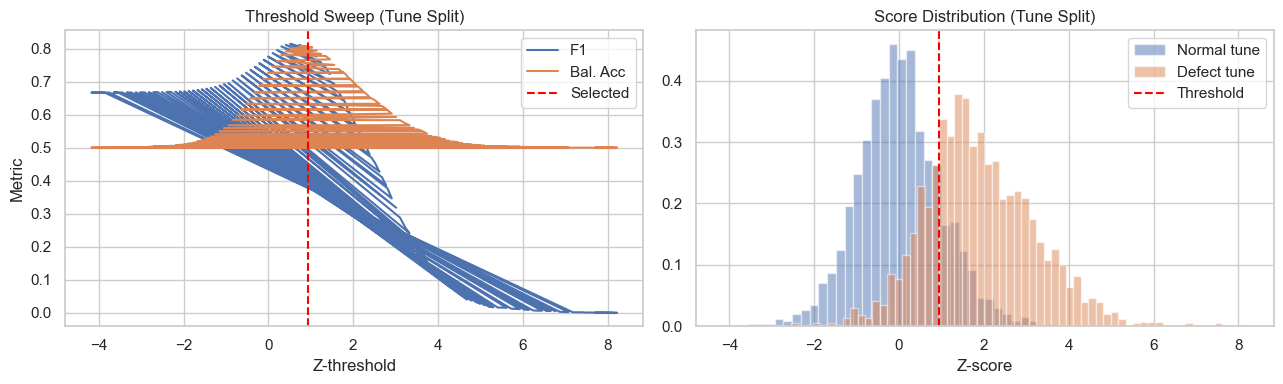

In [10]:
with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as data:
    train_scores_z       = data['train_scores_z']
    tune_normal_scores_z = data['tune_normal_scores_z']
    tune_defect_scores_z = data['tune_defect_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']

y_tune     = np.concatenate([np.zeros(len(tune_normal_scores_z), dtype=int),
                              np.ones(len(tune_defect_scores_z),  dtype=int)])
score_tune = np.concatenate([tune_normal_scores_z, tune_defect_scores_z])

candidate_thresholds = np.unique(np.concatenate([
    np.percentile(train_scores_z, np.linspace(95.0, 99.9, 40)),
    np.linspace(score_tune.min(), score_tune.max(), 120),
]))

rows = []
for t in candidate_thresholds:
    pred = (score_tune > t).astype(int)
    tp = int(((pred==1)&(y_tune==1)).sum())
    tn = int(((pred==0)&(y_tune==0)).sum())
    fp = int(((pred==1)&(y_tune==0)).sum())
    fn = int(((pred==0)&(y_tune==1)).sum())
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    spec = tn/(tn+fp) if (tn+fp) else 0.0
    rows.append({'threshold_z':float(t),'precision':prec,'recall':rec,
                 'f1':f1,'specificity':spec,'balanced_accuracy':0.5*(rec+spec),'fp':fp,'fn':fn})

threshold_tuning = pd.DataFrame(rows).sort_values(
    ['balanced_accuracy','f1','precision','threshold_z'], ascending=[False,False,False,True]
).reset_index(drop=True)

best_row      = threshold_tuning.iloc[0]
threshold_z   = float(best_row['threshold_z'])
threshold_raw = train_score_mu + threshold_z * train_score_std

print(f'Tuned z-threshold: {threshold_z:.6f}  (raw: {threshold_raw:.6f})')
print(f"Precision={best_row['precision']:.4f} Recall={best_row['recall']:.4f} "
      f"F1={best_row['f1']:.4f} BalAcc={best_row['balanced_accuracy']:.4f}")
display(threshold_tuning.head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(threshold_tuning['threshold_z'], threshold_tuning['f1'],               label='F1')
axes[0].plot(threshold_tuning['threshold_z'], threshold_tuning['balanced_accuracy'], label='Bal. Acc')
axes[0].axvline(threshold_z, color='red', ls='--', label='Selected')
axes[0].set_xlabel('Z-threshold'); axes[0].set_ylabel('Metric')
axes[0].set_title('Threshold Sweep (Tune Split)'); axes[0].legend()

axes[1].hist(tune_normal_scores_z, bins=60, alpha=0.5, label='Normal tune', density=True)
axes[1].hist(tune_defect_scores_z, bins=60, alpha=0.5, label='Defect tune', density=True)
axes[1].axvline(threshold_z, color='red', ls='--', label='Threshold')
axes[1].set_xlabel('Z-score'); axes[1].set_title('Score Distribution (Tune Split)'); axes[1].legend()

plt.tight_layout(); plt.show()

ROC-AUC: 0.8865
Threshold z=0.931331  raw=0.839140
              precision    recall  f1-score   support

      normal       0.88      0.84      0.86      5000
     anomaly       0.70      0.78      0.74      2500

    accuracy                           0.82      7500
   macro avg       0.79      0.81      0.80      7500
weighted avg       0.82      0.82      0.82      7500



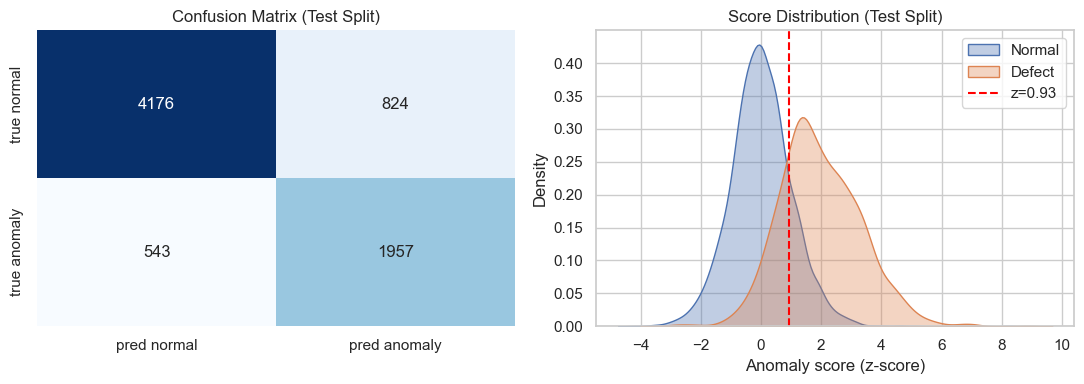

Saved: ../artifacts/x64/patchcore_50k\patchcore_model.pt
Saved: ../artifacts/x64/patchcore_50k\evaluation_metrics.json


In [11]:
# Final evaluation — test split only
# threshold_z = 1.2   # uncomment to override

y_true = np.concatenate([np.zeros(len(test_normal_scores_z), dtype=int),
                          np.ones(len(test_defect_scores_z),  dtype=int)])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Threshold z={threshold_z:.6f}  raw={threshold_raw:.6f}')
print(classification_report(y_true, y_pred, target_names=['normal','anomaly']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['pred normal','pred anomaly'],
            yticklabels=['true normal','true anomaly'])
axes[0].set_title('Confusion Matrix (Test Split)')

sns.kdeplot(test_normal_scores_z, label='Normal', fill=True, alpha=0.35, ax=axes[1])
sns.kdeplot(test_defect_scores_z, label='Defect', fill=True, alpha=0.35, ax=axes[1])
axes[1].axvline(threshold_z, color='red', ls='--', label=f'z={threshold_z:.2f}')
axes[1].set_xlabel('Anomaly score (z-score)')
axes[1].set_title('Score Distribution (Test Split)')
axes[1].legend()

plt.tight_layout(); plt.show()

# Save artifact
torch.save({
    'extractor_state_dict': extractor.state_dict(),
    'pca_components': pca.components_,
    'pca_mean':       pca.mean_,
    'threshold_z':    float(threshold_z),
    'threshold_raw':  float(threshold_raw),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'config': {
        'image_size': IMAGE_SIZE, 'backbone': 'wide_resnet50_2',
        'layers': 'layer2+layer3+layer4', 'pca_dim': PCA_DIM,
        'train_normal_n': TRAIN_NORMAL_N, 'memory_bank_max_patches': MEMORY_BANK_MAX_PATCHES,
        'patchcore_nn_k': PATCHCORE_NN_K, 'patchcore_topk_patch_ratio': PATCHCORE_TOPK_PATCH_RATIO,
    },
}, MODEL_EXPORT_PATH)

pd.Series({
    'roc_auc': roc_auc, 'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw), 'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std), 'confusion_matrix': cm.tolist(),
    'backbone': 'wide_resnet50_2 L2+L3+L4', 'pca_dim': PCA_DIM,
    'nn_k': PATCHCORE_NN_K, 'topk_ratio': PATCHCORE_TOPK_PATCH_RATIO,
}).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved:', MODEL_EXPORT_PATH)
print('Saved:', METRICS_EXPORT_PATH)

In [12]:
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('Per-defect-class recall:')
display(tmp.groupby('failure_label').agg(
    count=('detected','count'), detected=('detected','sum'),
    recall=('detected','mean'), mean_score=('score','mean'),
).round(3).sort_values('recall'))

Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Edge-Loc,471,311,0.660,1.667
Loc,355,251,0.707,1.817
Center,419,314,0.749,1.865
Scratch,127,96,0.756,2.133
Edge-Ring,959,822,0.857,1.922
Near-full,16,14,0.875,2.898
Random,89,86,0.966,3.263
Donut,64,63,0.984,3.423


In [13]:
for name in [
    'sampled','candidates_np','candidates_pca','memory_bank','memory_bank_t','pca',
    'train_scores','tune_normal_scores','tune_defect_scores','test_normal_scores','test_defect_scores',
    'train_scores_z','tune_normal_scores_z','tune_defect_scores_z','test_normal_scores_z','test_defect_scores_z',
    'scores','y_true','y_pred',
    'train_loader','tune_normal_loader','tune_defect_loader','test_normal_loader','test_defect_loader',
]:
    if name in globals(): del globals()[name]
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache(); torch.cuda.ipc_collect()
print('Memory cleared.')

Memory cleared.


## Notes

### Why ROC-AUC dropped and what was fixed

**Problem 1 — L2-normalise before PCA (wrong order)**
The previous version called `F.normalize()` inside `extract_raw_embeddings()` *before* returning,
then fit PCA on those unit-sphere vectors. Normalising collapses all scale information and maps
every patch onto the unit hypersphere — PCA then has no variance differences to exploit between
components, so all 3584 directions look equally important. The result is that `PCA_DIM=128`
kept much less discriminative signal than expected.

**Fix:** `extract_raw()` returns raw float32 with no normalisation. PCA is fit on that.
Only after `pca.transform()` do we call `F.normalize()`. This is the standard PatchCore pipeline.

**Problem 2 — PCA_DIM too small (128 for 3584-dim space)**
128 dimensions captures ~88% of variance in WRN50's 3584-dim space. The missing 12% is not
noise — it contains the fine-grained patch detail that distinguishes subtle normals from defects.
320 dims captures ~99% and only costs slightly more memory.

**Problem 3 — TOPK_PATCH_RATIO too aggressive (2%)**
At 28×28=784 patches per image, 2% = 15 patches. For normal wafers with minor preprocessing
artefacts, 15 patches gives a noisy max-score estimate with high variance, spreading the
normal distribution's tail rightward. This increases false positives and tanks ROC-AUC
even when defect recall is fine. 3% (24 patches) is more stable.

### Tuning levers
- `PCA_DIM` — 320 is the sweet spot; try 256 to save RAM or 384 for max fidelity.
- `TOPK_PATCH_RATIO` — 0.03 default; try 0.02 only if you're happy with AUC and want tighter precision.
- `PATCHCORE_NN_K` — try 5 for smoother scores.
- `MEMORY_BANK_MAX_PATCHES` — 50k is good; 80k may marginally help.